# Install Dependencies

In [1]:
!pip install -q opendatasets tensorflow matplotlib scikit-learn

You should consider upgrading via the 'C:\Users\154064\Downloads\DEBI\mask-detection\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


# Download Dataset from Kaggle

In [3]:
!kaggle datasets download -d ashishjangra27/face-mask-12k-images-dataset
!unzip face-mask-12k-images-dataset.zip

Traceback (most recent call last):
  File "C:\Program Files\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Program Files\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\154064\Downloads\DEBI\mask-detection\.venv\Scripts\kaggle.exe\__main__.py", line 7, in <module>
  File "C:\Users\154064\Downloads\DEBI\mask-detection\.venv\lib\site-packages\kaggle\cli.py", line 68, in main
    out = args.func(**command_args)
  File "C:\Users\154064\Downloads\DEBI\mask-detection\.venv\lib\site-packages\kaggle\api\kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
  File "C:\Users\154064\Downloads\DEBI\mask-detection\.venv\lib\site-packages\kaggle\api\kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
KeyError: 'username'
'unzip' is not recognized as an internal or external command,
oper

# Imports

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.21.0
GPU available: False


# Set Paths and Constants

In [6]:
import zipfile
import os

zip_path = r"C:\Users\154064\Downloads\DEBI\mask-detection\archive.zip"
extract_path = r"C:\Users\154064\Downloads\DEBI\mask-detection"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [13]:
BASE_DIR = r"C:\Users\154064\Downloads\DEBI\mask-detection\Face Mask Dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
VAL_DIR   = os.path.join(BASE_DIR, "Validation")
TEST_DIR  = os.path.join(BASE_DIR, "Test")

IMG_SIZE   = (128, 128)
BATCH_SIZE = 64
EPOCHS     = 1

# Verify
for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    for cls in os.listdir(d):
        full = os.path.join(d, cls)
        print(f"{full}: {len(os.listdir(full))} images")

C:\Users\154064\Downloads\DEBI\mask-detection\Face Mask Dataset\Train\WithMask: 5000 images
C:\Users\154064\Downloads\DEBI\mask-detection\Face Mask Dataset\Train\WithoutMask: 5000 images
C:\Users\154064\Downloads\DEBI\mask-detection\Face Mask Dataset\Validation\WithMask: 400 images
C:\Users\154064\Downloads\DEBI\mask-detection\Face Mask Dataset\Validation\WithoutMask: 400 images
C:\Users\154064\Downloads\DEBI\mask-detection\Face Mask Dataset\Test\WithMask: 483 images
C:\Users\154064\Downloads\DEBI\mask-detection\Face Mask Dataset\Test\WithoutMask: 509 images


# Data Generators

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.15,
)
val_datagen  = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
val_gen = val_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
)
test_gen = test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
)

print("Class indices:", train_gen.class_indices)
# Expected: {'WithMask': 0, 'WithoutMask': 1}

Found 10000 images belonging to 2 classes.
Found 800 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Class indices: {'WithMask': 0, 'WithoutMask': 1}


# Build Model (Transfer Learning)

In [15]:
base_model = MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(128, 128, 3)
)
base_model.trainable = False  # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# Train

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 126s 776ms/step - accuracy: 0.9719 - loss: 0.0738 - val_accuracy: 0.9887 - val_loss: 0.0270


# Plot Training Curves

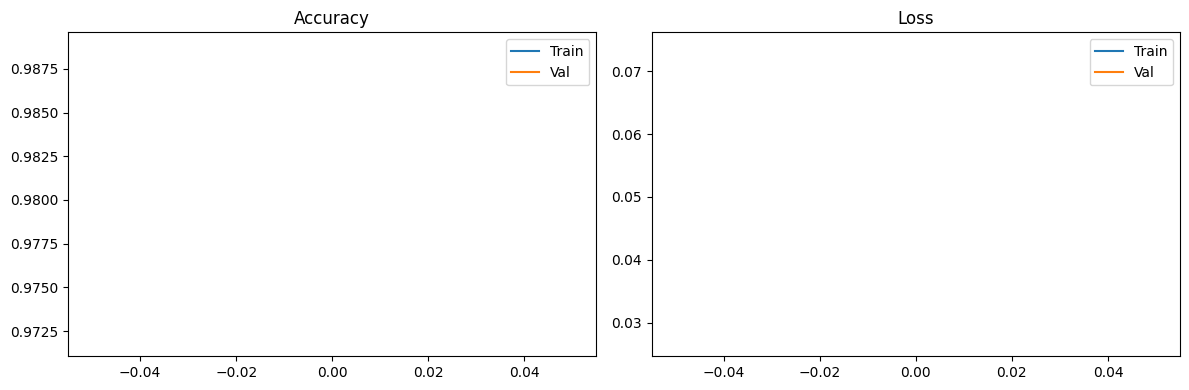

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluate on Test Set

In [18]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

# Classification report
preds = (model.predict(test_gen) > 0.5).astype(int).flatten()
print("\nClassification Report:")
print(classification_report(
    test_gen.classes, preds, target_names=["WithMask", "WithoutMask"]
))

# Confusion matrix
cm = confusion_matrix(test_gen.classes, preds)
print("Confusion Matrix:")
print(cm)

16/16 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step - accuracy: 0.9839 - loss: 0.0456

Test Accuracy: 0.9839
Test Loss:     0.0456
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 562ms/step

Classification Report:
              precision    recall  f1-score   support

    WithMask       0.97      1.00      0.98       483
 WithoutMask       1.00      0.97      0.98       509

    accuracy                           0.98       992
   macro avg       0.98      0.98      0.98       992
weighted avg       0.98      0.98      0.98       992

Confusion Matrix:
[[482   1]
 [ 15 494]]


# Save Model

In [22]:
# Save in Keras 3 native format
model.save("mask_detector_model.keras")

import os
print(f"Saved! Size: {os.path.getsize('mask_detector_model.keras') / 1e6:.1f} MB")

Saved! Size: 11.6 MB
